# GLM-5.x (Fireworks) vs Opus 4.8 & GPT-5 (OpenRouter) — throughput-under-load sweep

Fires batches of **GSM8K** requests at each provider at **increasing concurrency** (1 → 32) and plots how each one holds up under load:

- **Achieved throughput** (output tokens / sec) — does it keep scaling, or flatten?
- **p50 / p95 latency** — how much does queueing inflate per-request time as concurrency climbs?
- **TTFT** (time to first token, via streaming) — prefill time, which separates queueing-for-prefill from slow decode.
- **Decode tok/s per request (excl. prefill)** — the Artificial Analysis [Output Speed](https://artificialanalysis.ai/methodology/performance-benchmarking) metric, reported as median (sustained) and peak (fastest request); isolates decode speed from prefill/queueing.

This is a load test, not a capability benchmark — it rotates through a fixed set of real GSM8K questions as the workload. Uses `litellm` directly so we get raw timing + token usage per request.

**Prereqs:** `FIREWORKS_API_KEY` and `OPENROUTER_API_KEY` in `training/.env` or your shell. Anthropic (Opus 4.8) and OpenAI (GPT-5) are routed through OpenRouter, so a single OpenRouter key covers both; Fireworks is called directly.

## Metric definitions

Each request is streamed so we can split its wall time into prefill and decode:

- **TTFT** (time to first token) — seconds from sending the request to receiving the first content chunk. This is prefill time (ingesting + processing the prompt before decoding starts). Rises with input length and with queueing for prefill slots.
- **Latency** — total wall-clock per request (send → final chunk) = prefill + decode.
- **p50 / p95 latency** — median / 95th-percentile across all requests at that concurrency. p95 outrunning p50 = queueing / contention.
- **tok/s** (batch, `tokens_per_sec`) — `total_output_tokens / batch_wall_clock`, summed across every request at that concurrency. This is the **aggregate system throughput** (maps to AA's "system output throughput"). At c=1 it's roughly `sum(out_tokens) / sum(latencies)`; at higher c requests overlap so `wall` shrinks and this climbs until the server saturates.
- **dec t/s** (per-request, `decode_tok_per_sec`) — `out_tokens / (latency - TTFT)` for a single request, **prefill excluded**. This is the Artificial Analysis [Output Speed](https://artificialanalysis.ai/methodology/performance-benchmarking) definition. It isolates decode speed from prefill/queueing — it should *not* climb with concurrency (unlike batch tok/s); a flat curve means each request decodes at the same rate regardless of load, a dropping curve means decode is slowing under contention.
  - **dec med** (`tok_per_sec_per_req_p50`) — median across requests at that concurrency (sustained decode speed; the trustworthy number).
  - **peak** (`tok_per_sec_per_req_peak`) — max across requests (fastest single request).

> ⚠️ **Peak is inflated by short / bursty responses.** `dec t/s = out_tokens / (latency - TTFT)` divides by the *wall-clock decode window* (time between first and final chunk). If a response emits only a few tokens, or arrives in a single batched chunk right at the end, the decode window can be ~0.03s and `dec t/s` explodes to thousands — that measures network/chunk batching, not sustained generation. **Treat `dec med` as the headline number; treat `peak` as a best-case ceiling that's noisy for short responses.** A defensible peak would filter to requests with a meaningful decode window (e.g. ≥0.2s decode, or ≥50 tokens across multiple chunks).

> ⚠️ This sends a lot of requests (sum over all concurrency levels, × N models in `MODELS`). Mind rate limits and cost. Tune `CONCURRENCY_LEVELS` / `REQUESTS_PER_WORKER` down for a quick smoke test first.

In [1]:
# Run once if imports fail (uses the notebook kernel's Python).
import sys
!{sys.executable} -m pip install -q -e "../../.[eval]" matplotlib

In [2]:
# --- edit these: one row per model = (litellm id, reasoning extra_body, api_base, api_key_env) ---
# extra_body is forwarded verbatim (bypasses litellm's per-provider param validation).
# Fireworks/Together/Baseten take top-level reasoning_effort; OpenRouter takes reasoning:{...}.
MODELS_CFG = {
    "GLM-5.2 FAST (Fireworks)": ("fireworks_ai/accounts/fireworks/routers/glm-5p2-fast", {"reasoning_effort": "max"}, None, None),
    # "GLM-5.2 (Anonymous 1)":    ("together_ai/zai-org/GLM-5.2",                           {"reasoning_effort": "max"}, None, None),
    # "GLM-5.2 (Anonymous 2)":    ("openai/zai-org/GLM-5.2", {"reasoning_effort": "max"}, "https://inference.baseten.co/v1", "BASETEN_API_KEY"),
    "Kimi K3 (Fireworks)":      ("fireworks_ai/accounts/fireworks/models/kimi-k3",        {"reasoning_effort": "max"}, None, None),
}
REASONING_EFFORT = "max"   # set "" to disable reasoning and use each provider's default
MODELS         = {k: v[0] for k, v in MODELS_CFG.items()}
_REASONING_FOR = {v[0]: v[1] for v in MODELS_CFG.values()}
_API_BASE_FOR  = {v[0]: v[2] for v in MODELS_CFG.values() if v[2]}
_API_KEY_FOR   = {v[0]: v[3] for v in MODELS_CFG.values() if v[3]}

CONCURRENCY_LEVELS = [1, 2, 4, 8, 16]
CONCURRENCY_LEVELS = [1]
REQUESTS_PER_WORKER = 3          # at concurrency C we send C * REQUESTS_PER_WORKER requests
# Max-effort reasoning burns most of the budget thinking; give it room or the
# model never reaches a final answer and accuracy collapses to ~0.
MAX_TOKENS = 512                # fixed output budget so tokens/sec is comparable
# No temperature is sent: Opus 4.8 rejects the param, so for a fair comparison
# every model uses its own provider-default sampling.
REQUEST_TIMEOUT_S = 180

# Real workload: rotate through GSM8K questions instead of one canned prompt.
DATASET_URL = "https://raw.githubusercontent.com/eval-protocol/python-sdk/main/development/gsm8k_sample.jsonl"
NUM_PROMPTS = 16                 # distinct GSM8K questions to cycle through under load

In [3]:
import asyncio
import json
import os
import re
import time
import urllib.request
from pathlib import Path

import litellm
from dotenv import load_dotenv

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")

missing = [k for k in ("FIREWORKS_API_KEY", "OPENROUTER_API_KEY", "TOGETHER_API_KEY", "BASETEN_API_KEY") if not os.getenv(k)]
if missing:
    raise EnvironmentError(f"Missing {missing}. Set them in {training_dir / '.env'} or your shell.")

litellm.drop_params = False
# litellm._turn_on_debug()

# --- answer extraction (same regex as the other GSM8K notebooks) ---
_ANSWER_TAG_RE = re.compile(r"<answer>\s*(.*?)\s*</answer>", re.IGNORECASE | re.DOTALL)
_DIGITS_RE = re.compile(r"(-?\d+(?:\.\d+)?)")


def extract_answer(text: str) -> str | None:
    if not text:
        return None
    m = _ANSWER_TAG_RE.search(text)
    chunk = m.group(1) if m else text
    digits = _DIGITS_RE.findall(chunk.replace(",", ""))
    return digits[-1] if digits else None


def _kwargs_for(model: str) -> dict:
    """Per-model litellm.acompletion kwargs.

    Reasoning effort is always packed into `extra_body`: litellm forwards
    extra_body verbatim (the OpenAI SDK merges it into the request body), so
    this sidesteps litellm's per-provider param validation, which rejects
    `reasoning_effort` for slugs not in its model registry. Each provider's
    required body shape is built in _REASONING_FOR.

    Baseten is routed through litellm's generic `openai/` provider and also
    needs api_base + api_key overrides."""
    kw: dict = {}
    if REASONING_EFFORT:
        reasoning = _REASONING_FOR.get(model)
        if reasoning:
            kw["extra_body"] = dict(reasoning)
    base = _API_BASE_FOR.get(model)
    if base:
        kw["api_base"] = base
    key_env = _API_KEY_FOR.get(model)
    if key_env:
        kw["api_key"] = os.getenv(key_env)
    return kw


# Load GSM8K questions to use as the load-test workload. Each entry keeps the
# prompt messages plus the ground-truth answer so we can grade responses too.
_raw = urllib.request.urlopen(DATASET_URL).read().decode().splitlines()
PROMPTS = []  # list of {"messages": [...], "gt": "<digits>"}
for line in _raw[:NUM_PROMPTS]:
    if not line.strip():
        continue
    row = json.loads(line)
    msgs = [{"role": m["role"], "content": m["content"]}
            for m in row["messages"] if m["role"] in ("system", "user")]
    PROMPTS.append({"messages": msgs, "gt": extract_answer(str(row.get("ground_truth", "")))})
print(f"Loaded {len(PROMPTS)} GSM8K prompts (with ground-truth answers)")

Loaded 16 GSM8K prompts (with ground-truth answers)


## Sweep

For each concurrency level `C` we send `C * REQUESTS_PER_WORKER` requests through a semaphore of size `C`, keeping the pipe full. Each request uses one GSM8K question (cycled from `PROMPTS`). We record each request's latency and output-token count, then derive steady-state throughput from the batch wall-clock.

In [4]:
async def one_request(model: str, prompt: dict, sem: asyncio.Semaphore) -> dict:
    """Streaming request capturing TTFT + AA-style decode tok/s.

    Streaming so we can split latency into prefill (TTFT) and decode
    (latency - TTFT). Decode tok/s = out_tokens / (latency - ttft) excludes
    prefill -- the Artificial Analysis 'Output Speed' definition
    (https://artificialanalysis.ai/methodology/performance-benchmarking).
    """
    async with sem:
        t0 = time.perf_counter()
        ttft = None
        chunks = []
        last_ev = None
        try:
            stream = await litellm.acompletion(
                model=model,
                messages=prompt["messages"],
                max_tokens=MAX_TOKENS,
                timeout=REQUEST_TIMEOUT_S,
                stream=True,
                **_kwargs_for(model),
            )
            async for ev in stream:
                last_ev = ev
                delta = ev.choices[0].delta if getattr(ev, "choices", None) else None
                piece = getattr(delta, "content", None) if delta else None
                if piece:
                    if ttft is None:
                        ttft = time.perf_counter() - t0
                    chunks.append(piece)
            dt = time.perf_counter() - t0
            text = "".join(chunks)
            usage = getattr(last_ev, "usage", None) or getattr(stream, "usage", None)
            out_tok = getattr(usage, "completion_tokens", None) if usage else None
            if out_tok is None and text:
                out_tok = litellm.token_counter(model=model, text=text)
            decode_tps = (out_tok / (dt - ttft)) if (out_tok and ttft and dt > ttft) else 0.0
            pred = extract_answer(text)
            gt = prompt["gt"]
            score = 1.0 if (pred is not None and gt is not None and pred == gt) else 0.0
            return {"ok": True, "latency": dt,
                    "ttft": ttft if ttft is not None else float("nan"),
                    "decode_tok_per_sec": decode_tps,
                    "out_tokens": out_tok or 0, "score": score}
        except Exception as e:  # noqa: BLE001
            return {"ok": False, "latency": time.perf_counter() - t0, "error": repr(e)[:240],
                    "ttft": float("nan"), "decode_tok_per_sec": 0.0, "out_tokens": 0, "score": 0.0}


async def sweep_level(model: str, concurrency: int) -> dict:
    n = concurrency * REQUESTS_PER_WORKER
    sem = asyncio.Semaphore(concurrency)
    # Cycle through the GSM8K prompts so the workload is realistic and varied.
    batch = [PROMPTS[i % len(PROMPTS)] for i in range(n)]
    wall_start = time.perf_counter()
    out = await asyncio.gather(*(one_request(model, p, sem) for p in batch))
    wall = time.perf_counter() - wall_start

    ok = [r for r in out if r["ok"]]
    lats = sorted(r["latency"] for r in ok)
    total_out = sum(r["out_tokens"] for r in ok)

    def pct(p):
        return lats[min(len(lats) - 1, int(p * len(lats)))] if lats else float("nan")

    # Per-request decode tok/s (AA Output Speed): out_tokens / (latency - ttft),
    # excluding prefill. Unlike `tokens_per_sec` (total_out / wall, a batch-level
    # aggregate that grows with concurrency), this is the per-request decode
    # speed -- it stays flat if the provider serves each request at the same
    # speed regardless of load, and drops when per-request latency inflates
    # under contention. Peak = fastest single request at this concurrency.
    decode_tps = sorted(r["decode_tok_per_sec"] for r in ok if r["decode_tok_per_sec"] > 0)
    ttfts = sorted(r["ttft"] for r in ok if r["ttft"] == r["ttft"])  # drop NaN

    def pct_vals(vals, p):
        return vals[min(len(vals) - 1, int(p * len(vals)))] if vals else float("nan")

    return {
        "concurrency": concurrency,
        "n": n,
        "ok": len(ok),
        "errors": len(out) - len(ok),
        "first_error": next((r["error"] for r in out if not r["ok"] and r.get("error")), None),
        "wall": wall,
        "tokens_per_sec": (total_out / wall) if wall else 0.0,
        "tok_per_sec_per_req": (sum(decode_tps) / len(decode_tps)) if decode_tps else float("nan"),
        "tok_per_sec_per_req_p50": pct_vals(decode_tps, 0.50),
        "tok_per_sec_per_req_peak": max(decode_tps) if decode_tps else 0.0,
        "mean_ttft": (sum(ttfts) / len(ttfts)) if ttfts else float("nan"),
        "p95_ttft": pct_vals(ttfts, 0.95),
        "accuracy": (sum(r["score"] for r in ok) / len(ok)) if ok else float("nan"),
        "p50": pct(0.50),
        "p95": pct(0.95),
        "mean_latency": (sum(lats) / len(lats)) if lats else float("nan"),
        "reps": out,   # raw per-request dicts for inspection
    }


async def sweep_model(name: str, model: str) -> list[dict]:
    rows = []
    for c in CONCURRENCY_LEVELS:
        r = await sweep_level(model, c)
        rows.append(r)
        print(f"{name:24} c={c:>2}  ok={r['ok']:>3}/{r['n']:<3} err={r['errors']} "
              f"acc={r['accuracy']:>5.0%}  tok/s={r['tokens_per_sec']:>7.1f}  "
              f"ttft={r['mean_ttft']:>4.1f}s  p50={r['p50']:>5.1f}s  p95={r['p95']:>5.1f}s  "
              f"dec med={r['tok_per_sec_per_req_p50']:>5.1f}  peak={r['tok_per_sec_per_req_peak']:>5.1f}t/s")
        if r["errors"] and r["first_error"]:
            print(f"  first error: {r['first_error']}")
        # Per-request dump so you can inspect where peak/median come from.
        print(f"  {'#':>3} {'ok':>3} {'lat':>6} {'ttft':>6} {'out_tok':>7} {'dec t/s':>8}  note")
        for i, rep in enumerate(r["reps"]):
            if rep["ok"]:
                print(f"  {i:>3} {'ok':>3} {rep['latency']:>6.2f}s {rep['ttft']:>6.2f}s "
                      f"{rep['out_tokens']:>7} {rep['decode_tok_per_sec']:>8.1f}  "
                      f"{'CORRECT' if rep['score'] else 'wrong'}")
            else:
                print(f"  {i:>3} {'ERR':>3} {rep['latency']:>6.2f}s {'-':>6} {'-':>7} {'-':>8}  {rep.get('error','')[:60]}")
    return rows


sweep = {}
for name, model in MODELS.items():
    print(f"--- {name} ({model}) ---")
    sweep[name] = await sweep_model(name, model)

# Overall accuracy per model (mean across concurrency levels).
print()
for name, rows in sweep.items():
    accs = [r["accuracy"] for r in rows if r["accuracy"] == r["accuracy"]]  # drop NaN
    if accs:
        print(f"{name:24} overall accuracy (mean across levels): {sum(accs)/len(accs):.1%}")

--- GLM-5.2 FAST (Fireworks) (fireworks_ai/accounts/fireworks/routers/glm-5p2-fast) ---
GLM-5.2 FAST (Fireworks) c= 1  ok=  3/3   err=0 acc=   0%  tok/s=    8.5  ttft= 7.5s  p50= 11.4s  p95= 11.4s  dec med= 62.1  peak= 62.1t/s
    #  ok    lat   ttft out_tok  dec t/s  note
    0  ok  11.44s   7.54s     242     62.1  wrong
    1  ok   5.79s    nans       0      0.0  wrong
    2  ok  11.40s    nans       0      0.0  wrong
--- Kimi K3 (Fireworks) (fireworks_ai/accounts/fireworks/models/kimi-k3) ---
Kimi K3 (Fireworks)      c= 1  ok=  3/3   err=0 acc= 100%  tok/s=   23.5  ttft= 3.9s  p50=  7.3s  p95=  7.8s  dec med= 47.3  peak= 53.3t/s
    #  ok    lat   ttft out_tok  dec t/s  note
    0  ok   6.78s   4.58s     104     47.3  CORRECT
    1  ok   7.31s   3.85s     163     47.1  CORRECT
    2  ok   7.77s   3.14s     247     53.3  CORRECT

GLM-5.2 FAST (Fireworks) overall accuracy (mean across levels): 0.0%
Kimi K3 (Fireworks)      overall accuracy (mean across levels): 100.0%


## Curves

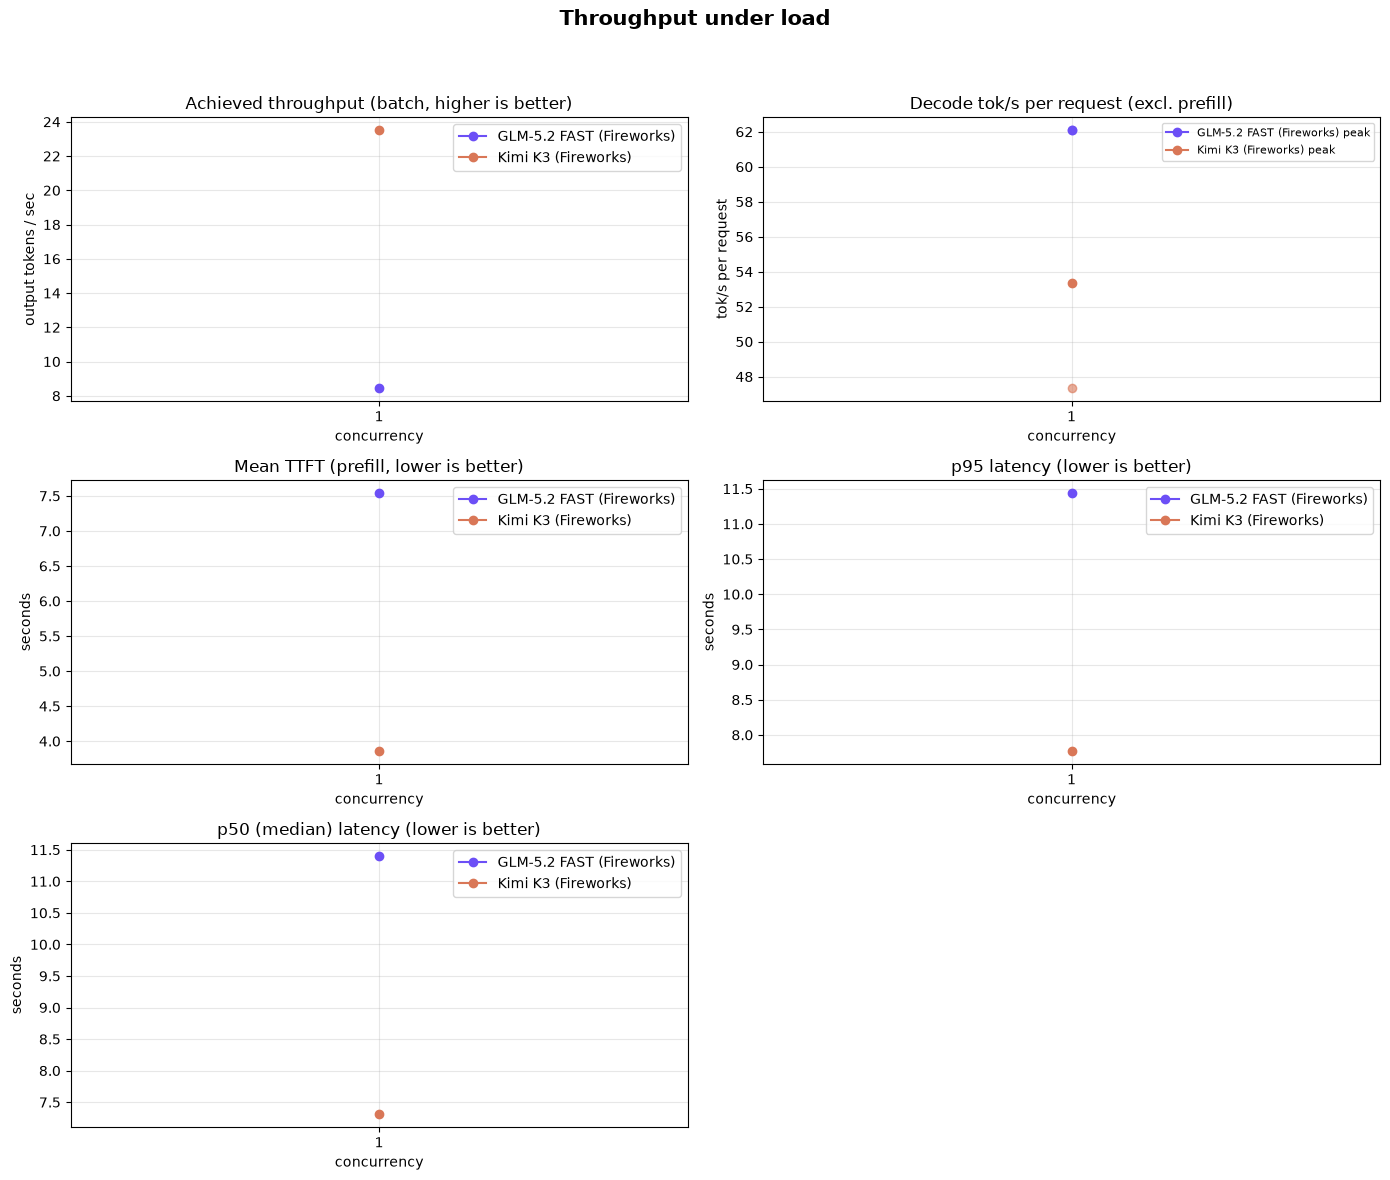

Saved gsm8k_throughput_sweep.png


In [5]:
import matplotlib.pyplot as plt
from itertools import cycle

names = list(sweep.keys())
# Map a palette across however many models are in MODELS (cycles if > palette size).
_palette = ["#6C4FF6", "#D97757", "#2E8B57", "#C2185B", "#1565C0", "#F9A825"]
colors = {n: c for n, c in zip(names, cycle(_palette))}

# Only 5 axes now, arrange as 3 rows x 2 columns (max 2 across)
n_plots = 5
n_cols = 2
n_rows = (n_plots + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12))
axes = axes.flatten()
fig.suptitle("Throughput under load", fontsize=15, fontweight="bold")

def line(ax, key, title, ylabel, pct=False):
    for n in names:
        xs = [r["concurrency"] for r in sweep[n]]
        ys = [(r[key] * 100 if pct else r[key]) for r in sweep[n]]
        ax.plot(xs, ys, "o-", label=n, color=colors[n])
    ax.set_title(title)
    ax.set_xlabel("concurrency"); ax.set_ylabel(ylabel)
    ax.set_xscale("log", base=2); ax.set_xticks(CONCURRENCY_LEVELS)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3); ax.legend()

line(axes[0], "tokens_per_sec", "Achieved throughput (batch, higher is better)", "output tokens / sec")
# Decode tok/s (AA Output Speed, excl. prefill): peak = fastest request, median = sustained.
for n in names:
    xs = [r["concurrency"] for r in sweep[n]]
    axes[1].plot(xs, [r["tok_per_sec_per_req_peak"] for r in sweep[n]], "o-",
                 label=f"{n} peak", color=colors[n])
    axes[1].plot(xs, [r["tok_per_sec_per_req_p50"] for r in sweep[n]], "o--",
                 color=colors[n], alpha=0.6)
axes[1].set_title("Decode tok/s per request (excl. prefill)")
axes[1].set_xlabel("concurrency"); axes[1].set_ylabel("tok/s per request")
axes[1].set_xscale("log", base=2); axes[1].set_xticks(CONCURRENCY_LEVELS)
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)
line(axes[2], "mean_ttft", "Mean TTFT (prefill, lower is better)", "seconds")
line(axes[3], "p95", "p95 latency (lower is better)", "seconds")
line(axes[4], "p50", "p50 (median) latency (lower is better)", "seconds")
# removed accuracy plot, so no axes[5] usage

# Hide any unused axes if the grid had to round up
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gsm8k_throughput_sweep.png", dpi=1000, bbox_inches="tight")
plt.show()
print("Saved gsm8k_throughput_sweep.png")

In [6]:
# Tabular dump for the record
for n in names:
    print(f"\n=== {n} ===")
    print(f"{'conc':>5} {'ok':>6} {'err':>4} {'acc':>5} {'tok/s':>9} {'ttft':>6} {'mean':>7} {'p95':>7} {'dec med':>8} {'dec peak':>9} {'wall':>7}")
    for r in sweep[n]:
        print(f"{r['concurrency']:>5} {r['ok']:>3}/{r['n']:<2} {r['errors']:>4} "
              f"{r['accuracy']:>5.0%} {r['tokens_per_sec']:>9.1f} {r['mean_ttft']:>6.2f} {r['mean_latency']:>7.2f} "
              f"{r['p95']:>7.2f} {r['tok_per_sec_per_req_p50']:>8.1f} {r['tok_per_sec_per_req_peak']:>9.1f} {r['wall']:>7.1f}")


=== GLM-5.2 FAST (Fireworks) ===
 conc     ok  err   acc     tok/s   ttft    mean     p95  dec med  dec peak    wall
    1   3/3     0    0%       8.5   7.54    9.54   11.44     62.1      62.1    28.6

=== Kimi K3 (Fireworks) ===
 conc     ok  err   acc     tok/s   ttft    mean     p95  dec med  dec peak    wall
    1   3/3     0  100%      23.5   3.86    7.29    7.77     47.3      53.3    21.9


### Reading the curves

- **Throughput that keeps climbing** with concurrency = the provider is scaling your load well. A **flattening / dropping** curve means you've hit a serving or rate-limit ceiling.
- **p95 rising much faster than p50** as concurrency climbs = queueing / contention — requests are waiting, not just generating.
- **TTFT (time to first token)** is measured with streaming; it's the prefill time before decode starts. TTFT rising with concurrency = requests are queueing for prefill slots, not just generating slowly. TTFT rising while decode tok/s stays flat = prefill-bound contention.
- **Decode tok/s per request (excl. prefill)** is the Artificial Analysis [Output Speed](https://artificialanalysis.ai/methodology/performance-benchmarking) metric: `out_tokens / (latency - TTFT)`, so prefill is excluded from the denominator. **Peak** = fastest single request at that concurrency; **median** = sustained. Unlike the batch-level `tokens/sec`, it does *not* climb with concurrency — it isolates per-request decode speed. A flat curve means each request decodes at the same speed regardless of load; a dropping curve means decode itself is slowing under contention (cross-request interference, KV-cache pressure).
- Fireworks (direct) and OpenRouter (proxying Anthropic/OpenAI) each enforce their own rate limits; a wall of `err` at high concurrency usually means you hit one (429), not that the model is slow. OpenRouter also retries across its backing providers, so errors there may show as elevated latency rather than outright failures. Check the printed `error` strings and back off `CONCURRENCY_LEVELS` if so.
- Output-token counts come from each provider's `usage.completion_tokens` (with a `litellm.token_counter` fallback when streaming usage isn't emitted); batch `tokens/sec` is steady-state (total output tokens ÷ batch wall-clock), so it already accounts for queueing.
- "Peak" here is **per-request peak decode speed**, not Artificial Analysis's "peak system throughput" (the latter is the batch `tokens/sec` curve's plateau, read off the first subplot at the concurrency where it stops climbing).